In [1]:
# Install dependencies (jalankan sekali saja)
!pip install pandas numpy matplotlib seaborn nltk scikit-learn

In [2]:
import re
import json
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('punkt_tab', quiet=True)

print('✅ Semua library berhasil diimport!')

✅ Semua library berhasil diimport!


---
## 1. Load Dataset

In [3]:
from google.colab import files
import zipfile, os

# Pastikan folder 'dataset' sudah ada
os.makedirs('dataset', exist_ok=True)

print('Silakan unggah file ZIP dataset Anda (misal: seg_train.zip dan seg_test.zip).')
uploaded = files.upload()

if not uploaded:
    print('Tidak ada file yang diupload. Harap unggah dataset ZIP yang diperlukan.')
else:
    for zip_filename in uploaded.keys():
        print(f'\n Memproses file: {zip_filename}')
        with zipfile.ZipFile(zip_filename, 'r') as z:
            z.extractall('dataset')
        print(f' Dataset dari {zip_filename} berhasil diekstrak ke folder dataset/')

print('\nSelesai proses upload dan ekstraksi dataset.')

Silakan unggah file ZIP dataset Anda (misal: seg_train.zip dan seg_test.zip).


Saving archive (2).zip to archive (2).zip

 Memproses file: archive (2).zip
 Dataset dari archive (2).zip berhasil diekstrak ke folder dataset/

Selesai proses upload dan ekstraksi dataset.


---
## 2. Eksplorasi Data Awal (EDA)

In [6]:
df = pd.read_csv('dataset/Resume/Resume.csv')
print('✅ Dataset berhasil dimuat ke DataFrame df!')

print('=== INFO DATASET ===')
print(df.info())
print('\n=== MISSING VALUES ===')
print(df.isnull().sum())

✅ Dataset berhasil dimuat ke DataFrame df!
=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2484 entries, 0 to 2483
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ID           2484 non-null   int64 
 1   Resume_str   2484 non-null   object
 2   Resume_html  2484 non-null   object
 3   Category     2484 non-null   object
dtypes: int64(1), object(3)
memory usage: 77.8+ KB
None

=== MISSING VALUES ===
ID             0
Resume_str     0
Resume_html    0
Category       0
dtype: int64


In [9]:
# Hitung panjang teks awal
df['resume_word_count'] = df['Resume_str'].str.split().str.len()
# df['jd_word_count']     = df['job_description'].str.split().str.len() # Kolom 'job_description' tidak ditemukan di DataFrame

print('Statistik panjang teks Resume:')
print(df['resume_word_count'].describe().round(1))
# print('Statistik panjang teks Job Description:')
# print(df['jd_word_count'].describe().round(1)) # Kolom 'jd_word_count' tidak dapat dihitung karena 'job_description' tidak ada

Statistik panjang teks Resume:
count    2484.0
mean      811.3
std       371.0
min         0.0
25%       651.0
50%       757.0
75%       933.0
max      5190.0
Name: resume_word_count, dtype: float64


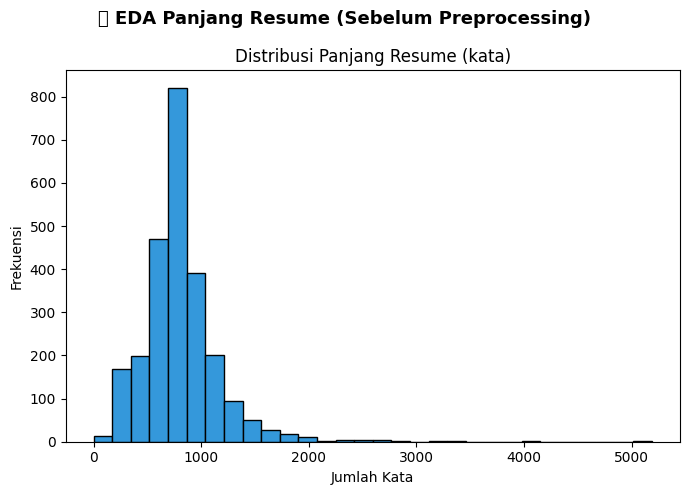

✅ Plot disimpan ke eda_before_resume.png


In [11]:
fig, axes = plt.subplots(1, 1, figsize=(7, 5)) # Ubah menjadi 1 subplot
fig.suptitle('📊 EDA Panjang Resume (Sebelum Preprocessing)', fontsize=13, fontweight='bold') # Sesuaikan judul

# Plot Distribusi panjang resume
axes.hist(df['resume_word_count'], bins=30, color='#3498db', edgecolor='black')
axes.set_title('Distribusi Panjang Resume (kata)')
axes.set_xlabel('Jumlah Kata')
axes.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_before_resume.png', dpi=150, bbox_inches='tight') # Sesuaikan nama file
plt.show()
print('✅ Plot disimpan ke eda_before_resume.png')

---
## 3. Handling Missing Values

In [13]:
total_before = len(df)
print(f'Total data sebelum : {total_before}')
print(f'\nMissing values per kolom:')
# Hanya cek untuk Resume_str karena kolom 'job_description' tidak ada
print(df[['Resume_str']].isnull().sum())

# Tidak perlu dropna untuk Resume_str karena tidak ada missing values,
# tetapi tetap periksa jika ada teks kosong
# df = df.dropna(subset=['Resume_str']) # Tidak ada missing values di Resume_str

# Drop baris yang teks-nya kosong di Resume_str
df = df[df['Resume_str'].str.strip() != '']

total_after = len(df)
print(f'\nTotal data setelah  : {total_after}')
print(f'Baris dihapus       : {total_before - total_after}')

Total data sebelum : 2484

Missing values per kolom:
Resume_str    0
dtype: int64

Total data setelah  : 2483
Baris dihapus       : 1


---
## 4. Cleaning & Preprocessing Teks

In [14]:
# Stopwords Inggris (dataset ini berbahasa Inggris)
STOPWORDS = set(stopwords.words('english'))

# Tambah custom stopwords yang tidak relevan untuk rekrutmen
CUSTOM_STOPWORDS = {
    'experienced','professional','skilled','needed','experience',
    'work','working','year','years','strong','ability','knowledge',
    'good','well','also','using','use','used'
}
STOPWORDS = STOPWORDS | CUSTOM_STOPWORDS

print(f'Total stopwords: {len(STOPWORDS)} kata')

Total stopwords: 216 kata


In [16]:
def clean_text(text: str) -> str:
    """
    Pipeline cleaning teks CV / Job Description:
    1. Lowercase
    2. Hapus URL & email
    3. Hapus karakter spesial & angka
    4. Hapus whitespace berlebih
    5. Tokenisasi
    6. Hapus stopwords & kata pendek (≤ 2 karakter)
    """
    if not isinstance(text, str) or text.strip() == '':
        return ''

    # 1. Lowercase
    text = text.lower()

    # 2. Hapus URL & email
    text = re.sub(r'http\S+|www\.\S+', ' ', text)
    text = re.sub(r'\S+@\S+', ' ', text)

    # 3. Hapus karakter spesial (pertahankan huruf & spasi)
    text = re.sub(r'[^a-z\s]', ' ', text)

    # 4. Hapus whitespace berlebih
    text = re.sub(r'\s+', ' ', text).strip()

    # 5. Tokenisasi
    tokens = word_tokenize(text)

    # 6. Hapus stopwords & kata pendek
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 2]

    return ' '.join(tokens)


# Test fungsi
sample_resume = df['Resume_str'].iloc[0]
# sample_jd     = df['job_description'].iloc[0] # Kolom 'job_description' tidak ada di dataset
print('=== RESUME SEBELUM ===')
print(sample_resume[:200])
print('\n=== RESUME SESUDAH ===')
print(clean_text(sample_resume)[:200])
# print('\n=== JD SEBELUM ===') # Kolom 'job_description' tidak ada di dataset
# print(sample_jd[:200])
# print('\n=== JD SESUDAH ===') # Kolom 'job_description' tidak ada di dataset
# print(clean_text(sample_jd)[:200])

=== RESUME SEBELUM ===
         HR ADMINISTRATOR/MARKETING ASSOCIATE

HR ADMINISTRATOR       Summary     Dedicated Customer Service Manager with 15+ years of experience in Hospitality and Customer Service Management.   Resp

=== RESUME SESUDAH ===
administrator marketing associate administrator summary dedicated customer service manager hospitality customer service management respected builder leader customer focused teams strives instill share


In [18]:
# Terapkan cleaning ke seluruh dataset
print('🔄 Membersihkan teks resume & job description...')

df['clean_resume'] = df['Resume_str'].apply(clean_text)
# df['clean_jd']     = df['job_description'].apply(clean_text) # Kolom 'job_description' tidak ada di dataset

# Hitung panjang teks sebelum & sesudah
df['resume_clean_len'] = df['clean_resume'].str.split().str.len()
# df['jd_clean_len']     = df['clean_jd'].str.split().str.len() # Kolom 'job_description' tidak ada di dataset

print('✅ Cleaning selesai!')
print(f'\nResume — rata-rata kata sebelum : {df["resume_word_count"].mean():.0f}')
print(f'Resume — rata-rata kata sesudah : {df["resume_clean_len"].mean():.0f}')
print(f'Reduksi : {(1 - df["resume_clean_len"].mean()/df["resume_word_count"].mean())*100:.1f}%')

🔄 Membersihkan teks resume & job description...
✅ Cleaning selesai!

Resume — rata-rata kata sebelum : 812
Resume — rata-rata kata sesudah : 570
Reduksi : 29.8%


---
## 5. Visualisasi Setelah Preprocessing

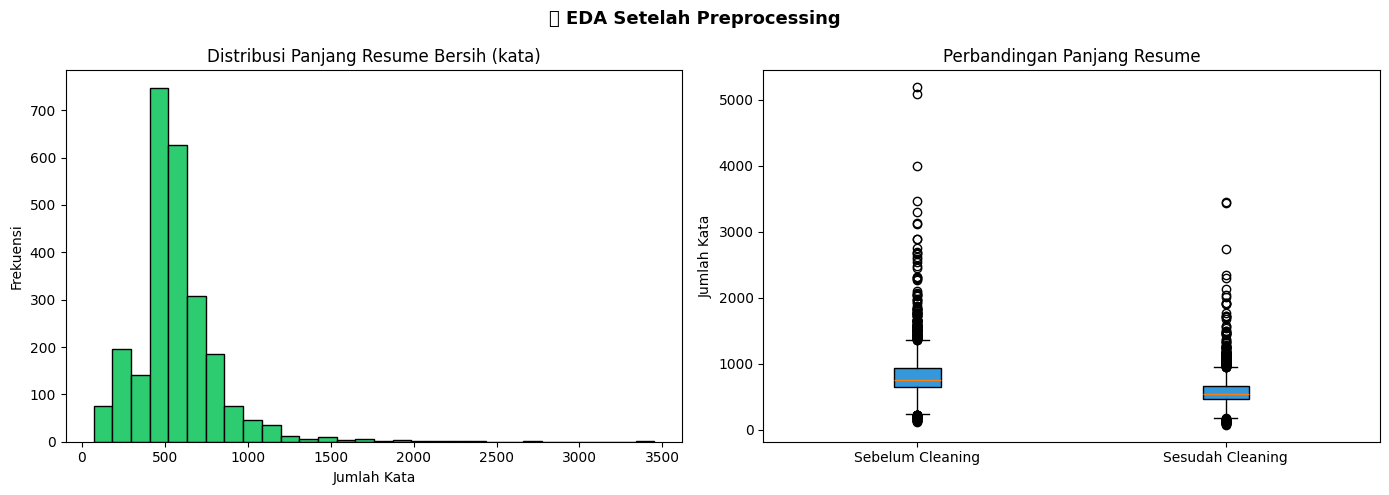

✅ Plot disimpan ke eda_after.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('📊 EDA Setelah Preprocessing', fontsize=13, fontweight='bold')

# Plot 1: Distribusi panjang resume bersih
axes[0].hist(df['resume_clean_len'], bins=30, color='#2ecc71', edgecolor='black')
axes[0].set_title('Distribusi Panjang Resume Bersih (kata)')
axes[0].set_xlabel('Jumlah Kata')
axes[0].set_ylabel('Frekuensi')

# Plot 2: Boxplot resume sebelum vs sesudah
axes[1].boxplot(
    [df['resume_word_count'], df['resume_clean_len']],
    labels=['Sebelum Cleaning', 'Sesudah Cleaning'],
    patch_artist=True,
    boxprops=dict(facecolor='#3498db', color='black')
)
axes[1].set_title('Perbandingan Panjang Resume')
axes[1].set_ylabel('Jumlah Kata')

plt.tight_layout()
plt.savefig('eda_after.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Plot disimpan ke eda_after.png')


---
## 6. Simpan Dataset Bersih

In [22]:
OUTPUT_CSV = 'cv_clean.csv'

cols_to_save = [
    'ID', 'Category', 'Resume_str', # Original columns for context
    'clean_resume', # The cleaned resume text
    'resume_word_count', 'resume_clean_len' # Word counts before and after cleaning
]

df_final = df[cols_to_save].reset_index(drop=True)
df_final.to_csv(OUTPUT_CSV, index=False, encoding='utf-8')

print(f'✅ Dataset bersih disimpan ke : {OUTPUT_CSV}')
print(f'   Total baris : {len(df_final)}')
print(f'   Kolom       : {df_final.columns.tolist()}')
print()
print('Preview dataset final:')
df_final.head(3)

✅ Dataset bersih disimpan ke : cv_clean.csv
   Total baris : 2483
   Kolom       : ['ID', 'Category', 'Resume_str', 'clean_resume', 'resume_word_count', 'resume_clean_len']

Preview dataset final:


,ID,Category,Resume_str,clean_resume,resume_word_count,resume_clean_len
0,16852973,HR,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,administrator marketing associate administrato...,674,486
1,22323967,HR,"HR SPECIALIST, US HR OPERATIONS ...",specialist operations summary versatile media ...,708,514
2,33176873,HR,HR DIRECTOR Summary Over 2...,director summary recruiting plus human resourc...,1017,683
